# EDA

In [49]:
import pandas as pd
import matplotlib.pyplot as plt

In [50]:
#importante verificar qual é o separador utilizado pelo arquivo csv

df = pd.read_csv("data.csv",sep=";")


In [51]:
df.dtypes

municipio      object
codEstacao     object
uf             object
nomeEstacao    object
latitude       object
longitude      object
datahora       object
valorMedida    object
dtype: object

In [52]:
# Quando for converter string para float, lembre-se de utilizar o método replace da classe str

df['datahora'] = pd.to_datetime(df['datahora'])
df['valorMedida'] = df['valorMedida'].str.replace(r',','.').astype(float)


In [53]:
df.head()

,municipio,codEstacao,uf,nomeEstacao,latitude,longitude,datahora,valorMedida
0,FRANCISCO MORATO,351630902A,SP,Jardim Vassouras,"-23,27571","-46,72153",2025-05-01 00:20:00,0.0
1,FRANCISCO MORATO,351630902A,SP,Jardim Vassouras,"-23,27571","-46,72153",2025-05-01 01:20:00,0.0
2,FRANCISCO MORATO,351630902A,SP,Jardim Vassouras,"-23,27571","-46,72153",2025-05-01 02:20:00,0.0
3,FRANCISCO MORATO,351630902A,SP,Jardim Vassouras,"-23,27571","-46,72153",2025-05-01 03:20:00,0.0
4,FRANCISCO MORATO,351630902A,SP,Jardim Vassouras,"-23,27571","-46,72153",2025-05-01 04:20:00,0.0


In [54]:
df['valorMedida'].max()

4.2

In [55]:
df['semana'] = df['datahora']
df['semana'] = df['semana'].dt.isocalendar().week
df['hora'] = df['datahora'].dt.hour

In [56]:
df[['datahora', 'semana']]


,datahora,semana
0,2025-05-01 00:20:00,18
1,2025-05-01 01:20:00,18
2,2025-05-01 02:20:00,18
3,2025-05-01 03:20:00,18
4,2025-05-01 04:20:00,18
...,...,...
3044,2025-05-30 19:00:00,22
3045,2025-05-30 20:00:00,22
3046,2025-05-30 21:00:00,22
3047,2025-05-30 22:00:00,22


In [57]:
max_pct_semana_2 = df.groupby(df['semana']).agg({'valorMedida': ['max'],
                                           'datahora': ['min', 'max']})

max_pct_semana_2


valorMedida   datahora                    
               max        min                 max
semana                                           
18             0.2 2025-05-01 2025-05-04 23:50:00
19             4.2 2025-05-05 2025-05-11 23:50:00
20             0.2 2025-05-12 2025-05-18 23:50:00
21             0.2 2025-05-19 2025-05-25 23:50:00
22             0.2 2025-05-26 2025-05-30 23:50:00

<Axes: xlabel='semana'>

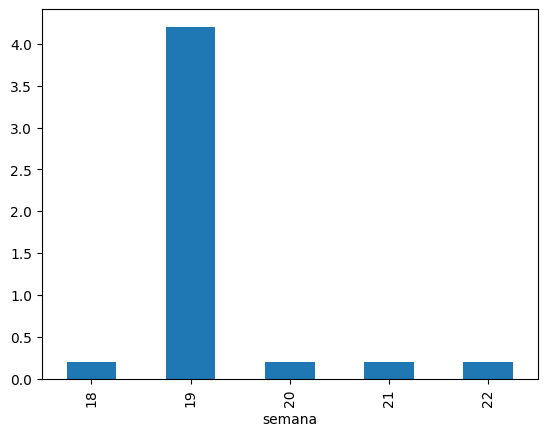

In [58]:
max_pct_semana = df.groupby('semana')['valorMedida'].max()

max_pct_semana.plot(kind='bar')

In [59]:
max_semana_19  = df[df['semana'] == 19]
max_semana_19

,municipio,codEstacao,uf,nomeEstacao,latitude,longitude,datahora,valorMedida,semana,hora
96,FRANCISCO MORATO,351630902A,SP,Jardim Vassouras,"-23,27571","-46,72153",2025-05-05 00:20:00,0.0,19,0
97,FRANCISCO MORATO,351630902A,SP,Jardim Vassouras,"-23,27571","-46,72153",2025-05-05 01:20:00,0.0,19,1
98,FRANCISCO MORATO,351630902A,SP,Jardim Vassouras,"-23,27571","-46,72153",2025-05-05 02:20:00,0.0,19,2
99,FRANCISCO MORATO,351630902A,SP,Jardim Vassouras,"-23,27571","-46,72153",2025-05-05 03:20:00,0.0,19,3
100,FRANCISCO MORATO,351630902A,SP,Jardim Vassouras,"-23,27571","-46,72153",2025-05-05 04:20:00,0.0,19,4
...,...,...,...,...,...,...,...,...,...,...
2580,FRANCISCO MORATO,351630906A,SP,Jardim Alegria,"-23,28834","-46,71155",2025-05-11 19:00:00,0.0,19,19
2581,FRANCISCO MORATO,351630906A,SP,Jardim Alegria,"-23,28834","-46,71155",2025-05-11 20:00:00,0.0,19,20
2582,FRANCISCO MORATO,351630906A,SP,Jardim Alegria,"-23,28834","-46,71155",2025-05-11 21:00:00,0.0,19,21
2583,FRANCISCO MORATO,351630906A,SP,Jardim Alegria,"-23,28834","-46,71155",2025-05-11 22:00:00,0.0,19,22


In [60]:
grupo_dia = max_semana_19.groupby('data')['valorMedida'].max()
grupo_dia

KeyError: 'data'

(array([0, 1, 2, 3, 4, 5, 6]),
 [Text(0, 0, '2025-05-05'),
  Text(1, 0, '2025-05-06'),
  Text(2, 0, '2025-05-07'),
  Text(3, 0, '2025-05-08'),
  Text(4, 0, '2025-05-09'),
  Text(5, 0, '2025-05-10'),
  Text(6, 0, '2025-05-11')])

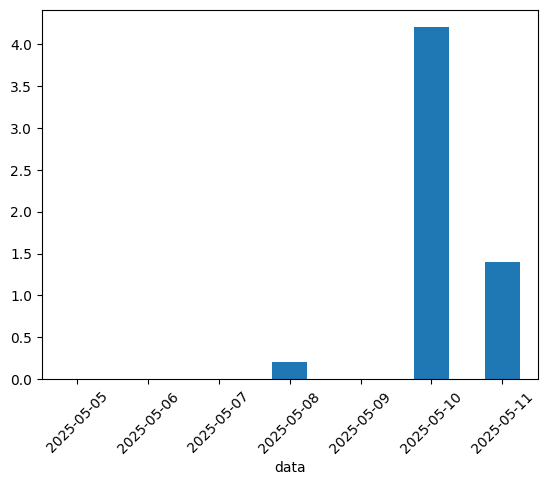

In [ ]:
grupo_dia.plot(kind='bar')
plt.xticks(rotation = 45)

In [ ]:
grupo_hora = df.groupby('hora')['valorMedida'].max()
grupo_hora

hora
0     1.4
1     0.2
2     0.2
3     0.0
4     0.2
5     0.0
6     0.0
7     0.2
8     0.2
9     0.2
10    0.2
11    0.2
12    0.0
13    0.0
14    0.2
15    0.0
16    0.0
17    0.0
18    0.2
19    4.2
20    0.8
21    1.6
22    1.6
23    0.8
Name: valorMedida, dtype: float64

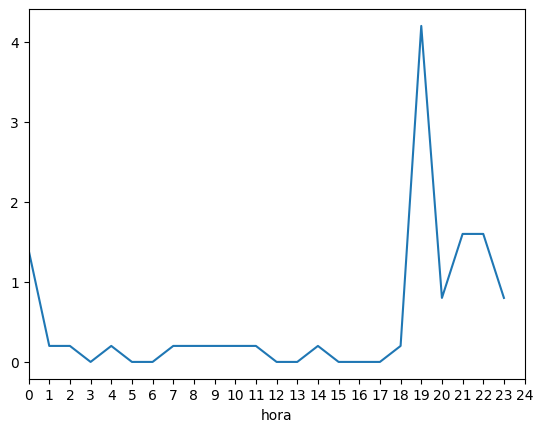

In [ ]:
grupo_hora.plot(kind='line')
plt.xlim(0,24)
plt.locator_params(axis='x', nbins=24)

# Data Analysis

In [62]:
sp_jan_2025 = pd.read_csv("sp_all_mncp_jan_2025.csv", sep=";")
df = sp_jan_2025

- Transformação 

In [63]:
df['datahora'] = pd.to_datetime(df['datahora'])
df['valorMedida'] = df['valorMedida'].str.replace(r',','.').astype(float)
df['semana'] = df['datahora']
df['semana'] = df['semana'].dt.isocalendar().week
df['hora'] = df['datahora'].dt.hour
df['data'] = df['datahora'].dt.date

- Análises

In [64]:
max_pct_semana_2 = df.groupby(df['semana']).agg({'valorMedida': ['max'],
                                           'datahora': ['min', 'max']})

max_pct_semana = df.groupby('semana')['valorMedida'].max()


In [65]:
max_pct_semana_2

valorMedida   datahora                    
               max        min                 max
semana                                           
1           353.09 2025-01-01 2025-01-05 23:50:00
2            46.79 2025-01-06 2025-01-12 23:50:00
3            82.03 2025-01-13 2025-01-19 23:50:00
4            31.20 2025-01-20 2025-01-26 23:50:00
5            79.93 2025-01-27 2025-01-31 23:50:00

(array([0, 1, 2, 3, 4]),
 [Text(0, 0, '1'),
  Text(1, 0, '2'),
  Text(2, 0, '3'),
  Text(3, 0, '4'),
  Text(4, 0, '5')])

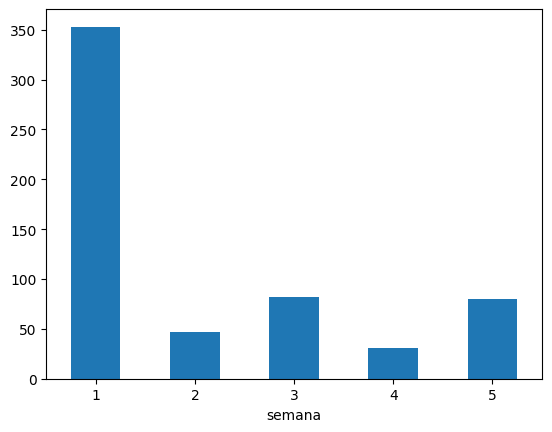

In [66]:
max_pct_semana.plot(kind='bar')
plt.xticks(rotation = 0)

In [67]:
max_semana_1  = df[df['semana'] == 1]
max_semana_2  = df[df['semana'] == 2]
max_semana_3  = df[df['semana'] == 3]
max_semana_4  = df[df['semana'] == 4]
max_semana_5  = df[df['semana'] == 5]

In [80]:
max_semana_1

,municipio,codEstacao,uf,nomeEstacao,latitude,longitude,datahora,valorMedida,semana,hora,data
0,ÁGUAS DE LINDÓIA,350050101A,SP,Jardim São Francisco,"-22,475","-46,628",2025-01-01 00:30:00,0.0,1,0,2025-01-01
1,ÁGUAS DE LINDÓIA,350050101A,SP,Jardim São Francisco,"-22,475","-46,628",2025-01-01 01:30:00,0.0,1,1,2025-01-01
2,ÁGUAS DE LINDÓIA,350050101A,SP,Jardim São Francisco,"-22,475","-46,628",2025-01-01 02:30:00,0.0,1,2,2025-01-01
3,ÁGUAS DE LINDÓIA,350050101A,SP,Jardim São Francisco,"-22,475","-46,628",2025-01-01 03:30:00,0.0,1,3,2025-01-01
4,ÁGUAS DE LINDÓIA,350050101A,SP,Jardim São Francisco,"-22,475","-46,628",2025-01-01 04:30:00,0.0,1,4,2025-01-01
...,...,...,...,...,...,...,...,...,...,...,...
455428,VOTORANTIM,355700601A,SP,Centro,"-23,545","-47,447",2025-01-05 19:10:00,0.0,1,19,2025-01-05
455429,VOTORANTIM,355700601A,SP,Centro,"-23,545","-47,447",2025-01-05 20:10:00,0.0,1,20,2025-01-05
455430,VOTORANTIM,355700601A,SP,Centro,"-23,545","-47,447",2025-01-05 21:10:00,0.0,1,21,2025-01-05
455431,VOTORANTIM,355700601A,SP,Centro,"-23,545","-47,447",2025-01-05 22:10:00,0.0,1,22,2025-01-05


In [187]:
estacoes_interesse = df[df['nomeEstacao'].isin(['AC Santana', 'Avenida Tucuruvi', 'Vila Maria'])]
estacoes_interesse = estacoes_interesse[estacoes_interesse['semana'] == 4]
estacoes_interesse.to_csv('dados_interesse.csv')

In [185]:
semana_diarizada_1 = max_semana_1.groupby('data')['valorMedida'].max()
semana_diarizada_2 = max_semana_2.groupby('data')['valorMedida'].max()
semana_diarizada_3 = max_semana_3.groupby('data')['valorMedida'].max()
semana_diarizada_4 = max_semana_4.groupby('data')['valorMedida'].max()
semana_diarizada_5 = max_semana_5.groupby('data')['valorMedida'].max()
grupo_semana = estacoes_interesse.groupby('data')['valorMedida'].sum()



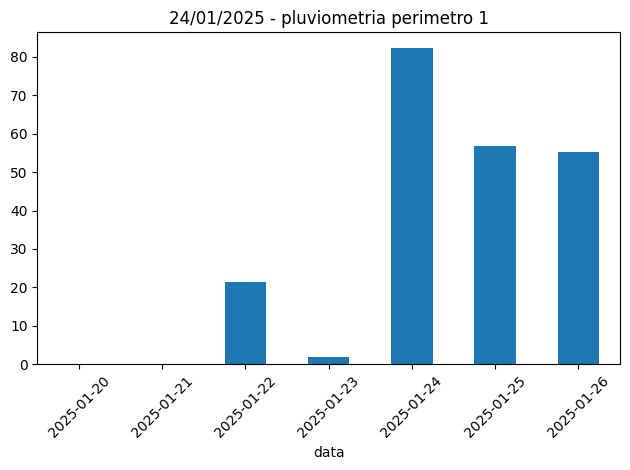

In [188]:
grupo_semana.plot(kind="bar")
plt.title('24/01/2025 - pluviometria perimetro 1')
plt.xticks(rotation = 45)
plt.tight_layout()

(array([0, 1, 2, 3, 4]),
 [Text(0, 0, '2025-01-01'),
  Text(1, 0, '2025-01-02'),
  Text(2, 0, '2025-01-03'),
  Text(3, 0, '2025-01-04'),
  Text(4, 0, '2025-01-05')])

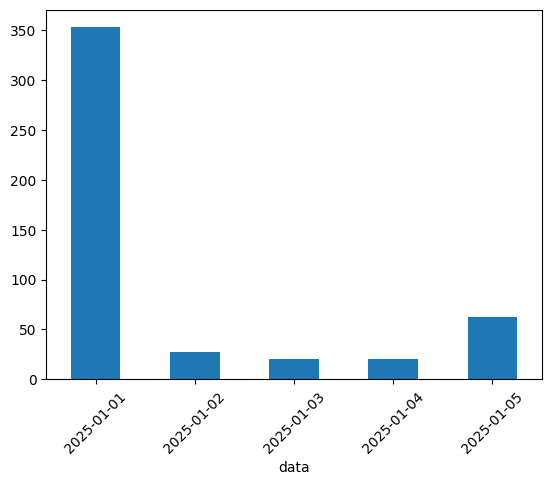

In [74]:
semana_diarizada_1.plot(kind="bar")
plt.xticks(rotation = 45)

(array([0, 1, 2, 3, 4, 5, 6]),
 [Text(0, 0, '2025-01-06'),
  Text(1, 0, '2025-01-07'),
  Text(2, 0, '2025-01-08'),
  Text(3, 0, '2025-01-09'),
  Text(4, 0, '2025-01-10'),
  Text(5, 0, '2025-01-11'),
  Text(6, 0, '2025-01-12')])

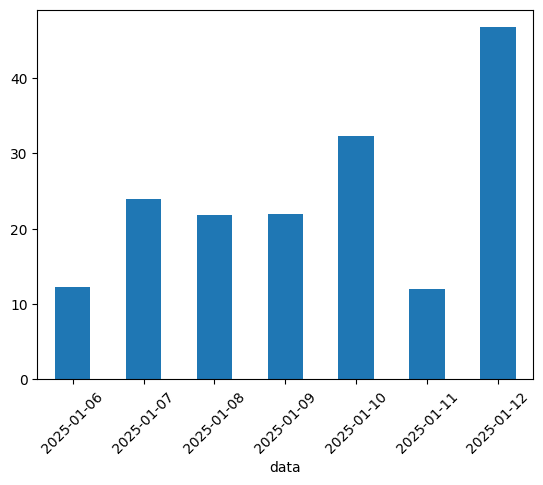

In [76]:
semana_diarizada_2.plot(kind="bar")
plt.xticks(rotation = 45)

(array([0, 1, 2, 3, 4, 5, 6]),
 [Text(0, 0, '2025-01-13'),
  Text(1, 0, '2025-01-14'),
  Text(2, 0, '2025-01-15'),
  Text(3, 0, '2025-01-16'),
  Text(4, 0, '2025-01-17'),
  Text(5, 0, '2025-01-18'),
  Text(6, 0, '2025-01-19')])

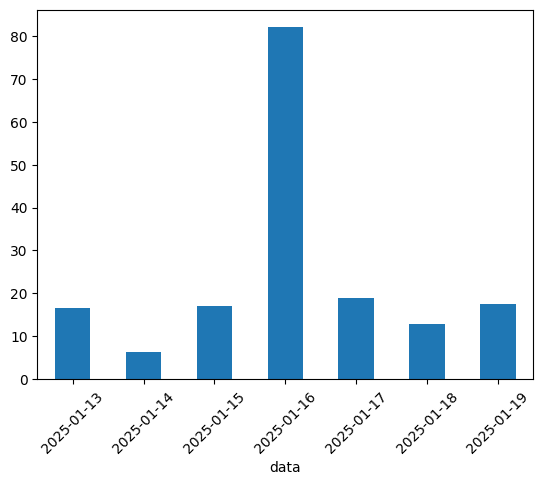

In [77]:
semana_diarizada_3.plot(kind="bar")
plt.xticks(rotation = 45)

(array([0, 1, 2, 3, 4, 5, 6]),
 [Text(0, 0, '2025-01-20'),
  Text(1, 0, '2025-01-21'),
  Text(2, 0, '2025-01-22'),
  Text(3, 0, '2025-01-23'),
  Text(4, 0, '2025-01-24'),
  Text(5, 0, '2025-01-25'),
  Text(6, 0, '2025-01-26')])

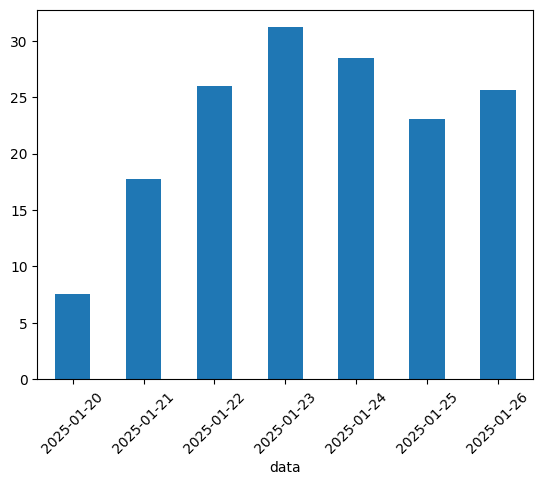

In [78]:
semana_diarizada_4.plot(kind="bar")
plt.xticks(rotation = 45)

(array([0, 1, 2, 3, 4]),
 [Text(0, 0, '2025-01-27'),
  Text(1, 0, '2025-01-28'),
  Text(2, 0, '2025-01-29'),
  Text(3, 0, '2025-01-30'),
  Text(4, 0, '2025-01-31')])

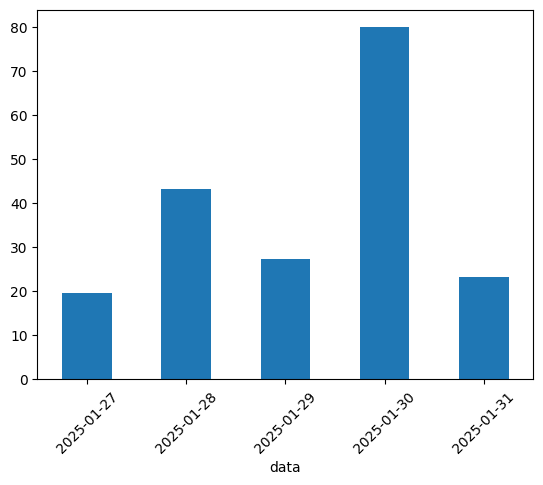

In [79]:
semana_diarizada_5.plot(kind="bar")
plt.xticks(rotation = 45)

In [ ]:
grupo_hora.plot(kind='line')
plt.xlim(0,24)
plt.locator_params(axis='x', nbins=24)